# RETOUCH 데이터 시각화

아래 셀은 다음 6개 폴더를 대상으로 데이터 구조와 기본 통계를 시각화합니다.

- `data/retouch/TrainingCirrus`
- `data/retouch/TrainingSpectralis`
- `data/retouch/TrainingTopcon`
- `data/retouch/TestTopcon`
- `data/retouch/TestSpectralis`
- `data/retouch/TestCirrus`

구성:
1. split별 케이스/파일 개수 요약
2. `oct.mhd` 헤더에서 읽은 볼륨 크기(DimSize) 분포 시각화
3. (`SimpleITK` 설치 시) split별 중간 슬라이스 샘플 표시

In [5]:
from pathlib import Path
from collections import defaultdict
import random
import re
import autorootcwd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path("data/retouch")
SPLITS = {
    "TrainingCirrus": ROOT / "TrainingCirrus" / "RETOUCH-TrainingSet-Cirrus",
    "TrainingSpectralis": ROOT / "TrainingSpectralis" / "RETOUCH-TrainingSet-Spectralis",
    "TrainingTopcon": ROOT / "TrainingTopcon" / "RETOUCH-TrainingSet-Topcon",
    "TestTopcon": ROOT / "TestTopcon" / "RETOUCH-TestSet-Topcon",
    "TestSpectralis": ROOT / "TestSpectralis" / "RETOUCH-TestSet-Spectralis",
    "TestCirrus": ROOT / "TestCirrus" / "RETOUCH-TestSet-Cirrus",
}

for split_name, split_path in SPLITS.items():
    if not split_path.exists():
        print(f"[WARN] Missing path: {split_name} -> {split_path}")


def parse_mhd_header(mhd_path: Path):
    """Parse minimal fields from .mhd text header."""
    fields = {}
    with mhd_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or "=" not in line:
                continue
            k, v = [x.strip() for x in line.split("=", 1)]
            fields[k] = v
    return fields


def parse_triplet(value: str):
    nums = re.findall(r"[-+]?\d*\.?\d+", value)
    if len(nums) >= 3:
        vals = [float(nums[0]), float(nums[1]), float(nums[2])]
        return vals
    return None

,split,n_cases,n_oct_mhd,n_ref_mhd,n_oct_raw,n_ref_raw
0,TestCirrus,14,14,0,14,0
1,TestSpectralis,14,14,0,14,0
2,TestTopcon,14,14,0,14,0
3,TrainingCirrus,24,24,24,24,24
4,TrainingSpectralis,24,24,24,24,24
5,TrainingTopcon,22,22,22,22,22


Total volume headers parsed: 112


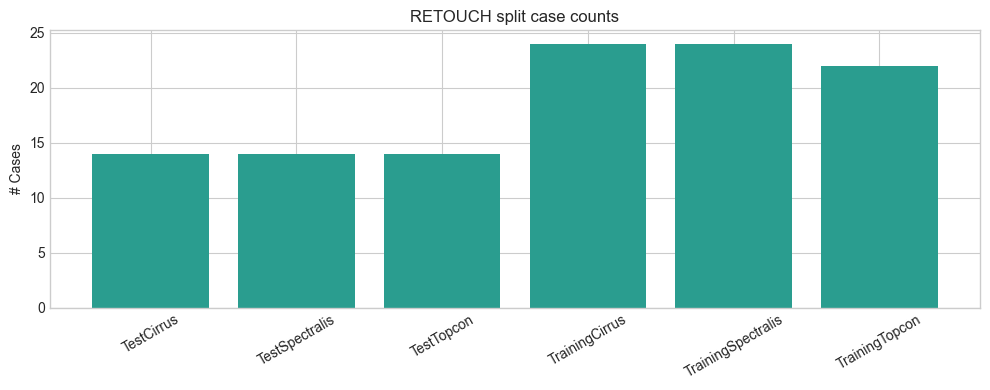

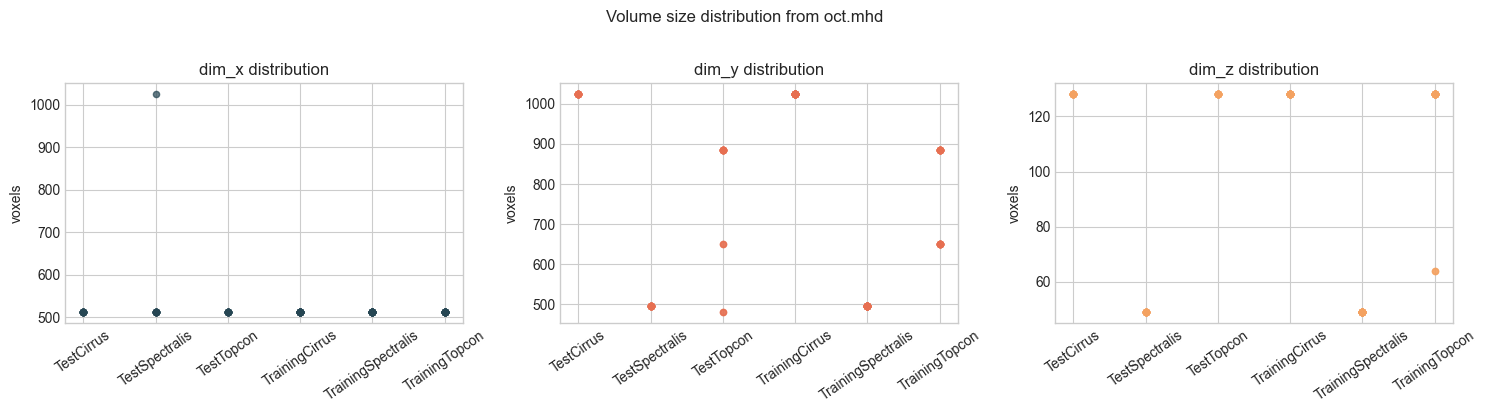

In [8]:
# 1) split별 케이스/파일 요약 + 2) oct.mhd 기반 shape/spacing 수집
rows = []
vol_rows = []

for split_name, split_path in SPLITS.items():
    case_dirs = sorted([p for p in split_path.iterdir() if p.is_dir()]) if split_path.exists() else []

    n_oct_mhd = 0
    n_ref_mhd = 0
    n_oct_raw = 0
    n_ref_raw = 0

    for cdir in case_dirs:
        oct_mhd = cdir / "oct.mhd"
        ref_mhd = cdir / "reference.mhd"
        oct_raw = cdir / "oct.raw"
        ref_raw = cdir / "reference.raw"

        if oct_mhd.exists():
            n_oct_mhd += 1
            hdr = parse_mhd_header(oct_mhd)
            dim = parse_triplet(hdr.get("DimSize", ""))
            spacing = parse_triplet(hdr.get("ElementSpacing", ""))
            if dim is not None:
                vol_rows.append({
                    "split": split_name,
                    "case": cdir.name,
                    "dim_x": int(dim[0]),
                    "dim_y": int(dim[1]),
                    "dim_z": int(dim[2]),
                    "spacing_x": spacing[0] if spacing is not None else np.nan,
                    "spacing_y": spacing[1] if spacing is not None else np.nan,
                    "spacing_z": spacing[2] if spacing is not None else np.nan,
                })

        if ref_mhd.exists():
            n_ref_mhd += 1
        if oct_raw.exists():
            n_oct_raw += 1
        if ref_raw.exists():
            n_ref_raw += 1

    rows.append({
        "split": split_name,
        "n_cases": len(case_dirs),
        "n_oct_mhd": n_oct_mhd,
        "n_ref_mhd": n_ref_mhd,
        "n_oct_raw": n_oct_raw,
        "n_ref_raw": n_ref_raw,
    })

summary_df = pd.DataFrame(rows).sort_values("split").reset_index(drop=True)
vol_df = pd.DataFrame(vol_rows)

display(summary_df)
print(f"Total volume headers parsed: {len(vol_df)}")

# Case count visualization
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(summary_df["split"], summary_df["n_cases"], color="#2A9D8F")
ax.set_title("RETOUCH split case counts")
ax.set_ylabel("# Cases")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

if not vol_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col, color in zip(axes, ["dim_x", "dim_y", "dim_z"], ["#264653", "#E76F51", "#F4A261"]):
        for split_name, g in vol_df.groupby("split"):
            ax.scatter([split_name] * len(g), g[col], alpha=0.7, s=20, color=color)
        ax.set_title(f"{col} distribution")
        ax.set_ylabel("voxels")
        ax.tick_params(axis="x", rotation=35)
    plt.suptitle("Volume size distribution from oct.mhd", y=1.02)
    plt.tight_layout()
    plt.show()

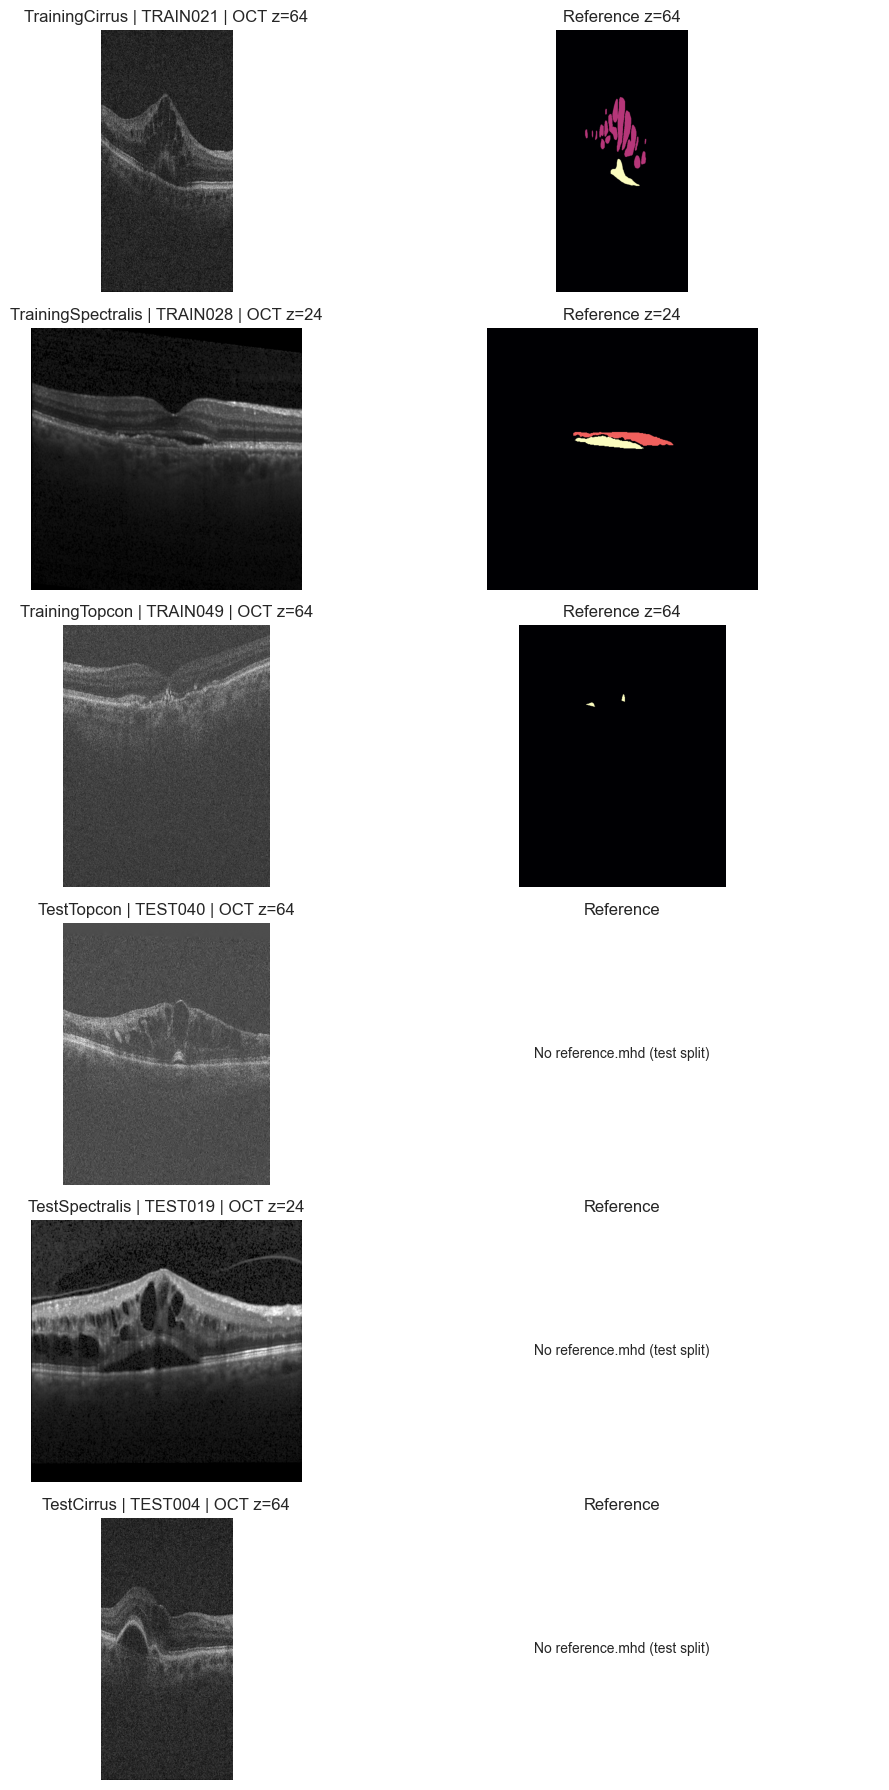

In [9]:
# 3) (Optional) Show middle slices when SimpleITK is available
try:
    import SimpleITK as sitk
    sitk_available = True
except Exception:
    sitk_available = False

if not sitk_available:
    print("SimpleITK is not installed, so slice visualization is skipped.")
    print("Install in .venv: .venv/bin/python -m pip install SimpleITK")
else:
    rng = random.Random(42)

    samples = []
    for split_name, split_path in SPLITS.items():
        case_dirs = sorted([p for p in split_path.iterdir() if p.is_dir()]) if split_path.exists() else []
        if not case_dirs:
            continue
        picked = rng.choice(case_dirs)
        samples.append((split_name, picked))

    n = len(samples)
    fig, axes = plt.subplots(n, 2, figsize=(10, 3 * n))
    if n == 1:
        axes = np.array([axes])

    for r, (split_name, case_dir) in enumerate(samples):
        oct_path = case_dir / "oct.mhd"
        ref_path = case_dir / "reference.mhd"

        if oct_path.exists():
            oct_img = sitk.ReadImage(str(oct_path))
            oct_arr = sitk.GetArrayFromImage(oct_img)  # [z, y, x]
            z = oct_arr.shape[0] // 2
            axes[r, 0].imshow(oct_arr[z], cmap="gray")
            axes[r, 0].set_title(f"{split_name} | {case_dir.name} | OCT z={z}")
        else:
            axes[r, 0].text(0.5, 0.5, "No oct.mhd", ha="center", va="center")
            axes[r, 0].set_title(f"{split_name} | {case_dir.name}")
        axes[r, 0].axis("off")

        if ref_path.exists():
            ref_img = sitk.ReadImage(str(ref_path))
            ref_arr = sitk.GetArrayFromImage(ref_img)
            z_ref = ref_arr.shape[0] // 2
            axes[r, 1].imshow(ref_arr[z_ref], cmap="magma")
            axes[r, 1].set_title(f"Reference z={z_ref}")
        else:
            axes[r, 1].text(0.5, 0.5, "No reference.mhd (test split)", ha="center", va="center")
            axes[r, 1].set_title("Reference")
        axes[r, 1].axis("off")

    plt.tight_layout()
    plt.show()